# LendingClub Credit Scorecard v2 — Expanded Feature Set

Revamps the `fico_percentile` scorecard from `scorecard.ipynb` with additional
engineered features, using the same validated methodology: WOE binning fit on
train only, IV-based selection, out-of-time validation (train 2007–2015, test
2016), and the same exclusions (no `grade`/`sub_grade`/`int_rate`/`installment`;
FICO handled as a rolling percentile, not a raw score — see `scorecard.ipynb` for
the full rationale on both).

**New this version:**
- `credit_history_years` — age of the borrower's credit file (`issue_d` − `earliest_cr_line`)
- `loan_to_income` — loan amount relative to annual income (distinct from `dti`, which covers total monthly debt payments)
- `mths_since_last_delinq`, `mths_since_last_record`, `mths_since_last_major_derog` — derogatory-event recency
- `acc_now_delinq`, `tax_liens` — current delinquency/lien counts
- `addr_state` — geographic risk

**Deliberately left out:** `revol_bal_to_limit` and a revolving/installment credit-mix
ratio were considered but dropped — they depend on `total_rev_hi_lim`, `num_rev_accts`,
and `num_il_tl`, which LendingClub did not start collecting until ~2013 (100% missing
2007–2011, 52% missing in 2012, 0% missing from 2013 onward, confirmed by checking
missingness by issue year directly). Since the training window starts in 2007 and the
2016 test set is fully populated, that missingness pattern tracks *loan vintage*, not
*credit risk* — a WOE bin built on it would risk encoding "this loan is recent" rather
than any real signal, so these were excluded from this iteration.

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print("Dataset path:", path)

Dataset path: /Users/andreastio/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


## 1. Load & prepare data

In [2]:
usecols = [
    "loan_amnt", "term", "emp_length", "home_ownership", "annual_inc",
    "verification_status", "issue_d", "loan_status", "purpose", "dti",
    "delinq_2yrs", "inq_last_6mths", "fico_range_low", "fico_range_high",
    "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
    "mort_acc", "pub_rec_bankruptcies",
    "earliest_cr_line", "mths_since_last_delinq", "mths_since_last_record",
    "mths_since_last_major_derog", "acc_now_delinq", "tax_liens", "addr_state",
]

csv_path = f"{path}/accepted_2007_to_2018Q4.csv.gz"
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
print(df.shape)

(2260701, 28)


In [3]:
def parse_emp_length(x):
    if pd.isna(x):
        return np.nan
    if "<" in x:
        return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["term_months"] = df["term"].str.extract(r"(\d+)").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%").replace("nan", np.nan).astype(float)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")
df["emp_length_years"] = df["emp_length"].apply(parse_emp_length)
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

df["credit_history_years"] = (df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25
df.loc[df["credit_history_years"] < 0, "credit_history_years"] = np.nan  # guard against any bad dates

df["loan_to_income"] = df["loan_amnt"] / df["annual_inc"].replace(0, np.nan)

bad_statuses = ["Charged Off", "Default"]
good_statuses = ["Fully Paid"]
resolved = df[df["loan_status"].isin(bad_statuses + good_statuses)].copy()
resolved["is_default"] = resolved["loan_status"].isin(bad_statuses).astype(int)

train = resolved[resolved["issue_d"] < "2016-01-01"].copy()
test = resolved[(resolved["issue_d"] >= "2016-01-01") & (resolved["issue_d"] < "2017-01-01")].copy()

train_default_rate = train["is_default"].mean()
test_default_rate = test["is_default"].mean()
print(f"Train (issued < 2016): {len(train):,} loans, default rate {train_default_rate:.2%}")
print(f"Test  (issued 2016)  : {len(test):,} loans, default rate {test_default_rate:.2%}")
print(train[["credit_history_years", "loan_to_income"]].describe())

Train (issued < 2016): 826,606 loans, default rate 18.43%
Test  (issued 2016)  : 293,105 loans, default rate 23.29%
       credit_history_years  loan_to_income
count         826606.000000   826604.000000
mean              16.241882        0.217623
std                7.445310        0.111938
min                2.997947        0.000309
25%               11.167693        0.130435
50%               14.748802        0.202710
75%               20.000000        0.295918
max               71.000684       10.000000


## 2. FICO as a rolling-percentile feature

Same construction as `scorecard.ipynb` — percentile rank against a trailing 6-month window of prior originations.

In [4]:
K_MONTHS = 6

df["issue_month"] = df["issue_d"].dt.to_period("M")

month_ficos = (
    df.dropna(subset=["fico_mid"])
    .groupby("issue_month")["fico_mid"]
    .apply(lambda s: np.sort(s.values))
    .sort_index()
)
all_months = month_ficos.index.tolist()

reference_by_month = {}
for i, m in enumerate(all_months):
    ref_months = all_months[max(0, i - K_MONTHS):i]
    if ref_months:
        reference_by_month[m] = np.sort(np.concatenate([month_ficos[mm] for mm in ref_months]))
    else:
        reference_by_month[m] = month_ficos[m]


def _percentile_within_group(group):
    ref = reference_by_month.get(group.name, np.array([]))
    if len(ref) == 0:
        return pd.Series(np.nan, index=group.index)
    idx = np.searchsorted(ref, group["fico_mid"].values, side="left")
    return pd.Series(idx / len(ref), index=group.index)


df["fico_percentile"] = df.groupby("issue_month", group_keys=False).apply(_percentile_within_group)
df.loc[df["fico_mid"].isna(), "fico_percentile"] = np.nan

train["fico_percentile"] = df.loc[train.index, "fico_percentile"]
test["fico_percentile"] = df.loc[test.index, "fico_percentile"]

## 3. WOE binning

Bin edges / category groupings are derived **only from the training set**, then applied unchanged to the test set.

In [5]:
NUMERIC_FEATURES = [
    "loan_amnt", "annual_inc", "dti", "delinq_2yrs", "fico_percentile",
    "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util",
    "total_acc", "mort_acc", "pub_rec_bankruptcies", "emp_length_years",
    "credit_history_years", "loan_to_income",
    "mths_since_last_delinq", "mths_since_last_record", "mths_since_last_major_derog",
    "acc_now_delinq", "tax_liens",
]
CATEGORICAL_FEATURES = ["home_ownership", "verification_status", "purpose", "term_months", "addr_state"]

MISSING_LABEL = "Missing"
RARE_LABEL = "Other"
EPS = 0.5


def fit_numeric_bins(series, n_bins=10):
    valid = series.dropna()
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(valid.quantile(quantiles).values)
    edges[0] = -np.inf
    edges[-1] = np.inf
    if len(edges) < 3:
        edges = np.array([-np.inf, np.inf])
    return edges


def apply_numeric_bins(series, edges):
    binned = pd.cut(series, bins=edges, include_lowest=True)
    return binned.astype("object").where(series.notna(), MISSING_LABEL)


def fit_categorical_groups(series, min_share=0.01):
    freq = series.value_counts(normalize=True, dropna=False)
    return set(freq[freq >= min_share].index)


def apply_categorical_groups(series, keep):
    return series.where(series.isin(keep), RARE_LABEL).fillna(MISSING_LABEL)


def compute_woe_table(binned_train, target_train):
    tab = pd.DataFrame({"bin": binned_train, "target": target_train})
    grp = tab.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grp.columns = ["n", "bad"]
    grp["good"] = grp["n"] - grp["bad"]
    total_good, total_bad = grp["good"].sum(), grp["bad"].sum()
    grp["good_rate"] = (grp["good"] + EPS) / (total_good + EPS * len(grp))
    grp["bad_rate"] = (grp["bad"] + EPS) / (total_bad + EPS * len(grp))
    grp["woe"] = np.log(grp["good_rate"] / grp["bad_rate"])
    grp["iv_component"] = (grp["good_rate"] - grp["bad_rate"]) * grp["woe"]
    return grp


bin_edges, cat_groups, woe_tables, iv_summary = {}, {}, {}, {}

for feat in NUMERIC_FEATURES:
    edges = fit_numeric_bins(train[feat])
    bin_edges[feat] = edges
    binned_train = apply_numeric_bins(train[feat], edges)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

for feat in CATEGORICAL_FEATURES:
    keep = fit_categorical_groups(train[feat])
    cat_groups[feat] = keep
    binned_train = apply_categorical_groups(train[feat], keep)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

iv_series = pd.Series(iv_summary).sort_values(ascending=False)
iv_series

term_months                    0.240284
loan_to_income                 0.125298
fico_percentile                0.109975
dti                            0.074887
verification_status            0.051283
loan_amnt                      0.036846
annual_inc                     0.031302
mort_acc                       0.027201
revol_util                     0.022246
home_ownership                 0.020853
purpose                        0.019845
inq_last_6mths                 0.018251
addr_state                     0.010395
credit_history_years           0.009429
open_acc                       0.007920
emp_length_years               0.006477
mths_since_last_record         0.006339
mths_since_last_major_derog    0.005276
revol_bal                      0.003456
mths_since_last_delinq         0.002442
delinq_2yrs                    0.001353
pub_rec                        0.000983
pub_rec_bankruptcies           0.000692
total_acc                      0.000367
tax_liens                      0.000083


### Information Value reference

| IV range | Predictive power |
|---|---|
| < 0.02 | Not useful |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| 0.3 – 0.5 | Strong |
| > 0.5 | Suspiciously strong (check for leakage) |

New features are marked in the printed IV table above by name — worth checking
where `credit_history_years`, `loan_to_income`, `addr_state`, and the recency
fields land before assuming they help.

In [6]:
SELECTED_FEATURES = iv_series[iv_series >= 0.02].index.tolist()
new_features = {
    "credit_history_years", "loan_to_income", "addr_state",
    "mths_since_last_delinq", "mths_since_last_record", "mths_since_last_major_derog",
    "acc_now_delinq", "tax_liens",
}
selected_new = [f for f in SELECTED_FEATURES if f in new_features]
dropped_new = [f for f in new_features if f not in SELECTED_FEATURES]
print(f"Selected {len(SELECTED_FEATURES)} of {len(iv_series)} features (IV >= 0.02):")
print(SELECTED_FEATURES)
print(f"\nOf the new features, {len(selected_new)} cleared the IV bar: {selected_new}")
print(f"Dropped (IV < 0.02): {dropped_new}")

Selected 10 of 26 features (IV >= 0.02):
['term_months', 'loan_to_income', 'fico_percentile', 'dti', 'verification_status', 'loan_amnt', 'annual_inc', 'mort_acc', 'revol_util', 'home_ownership']

Of the new features, 1 cleared the IV bar: ['loan_to_income']
Dropped (IV < 0.02): ['acc_now_delinq', 'mths_since_last_major_derog', 'tax_liens', 'addr_state', 'mths_since_last_delinq', 'credit_history_years', 'mths_since_last_record']


## 4. Check WOE monotonicity for top numeric features

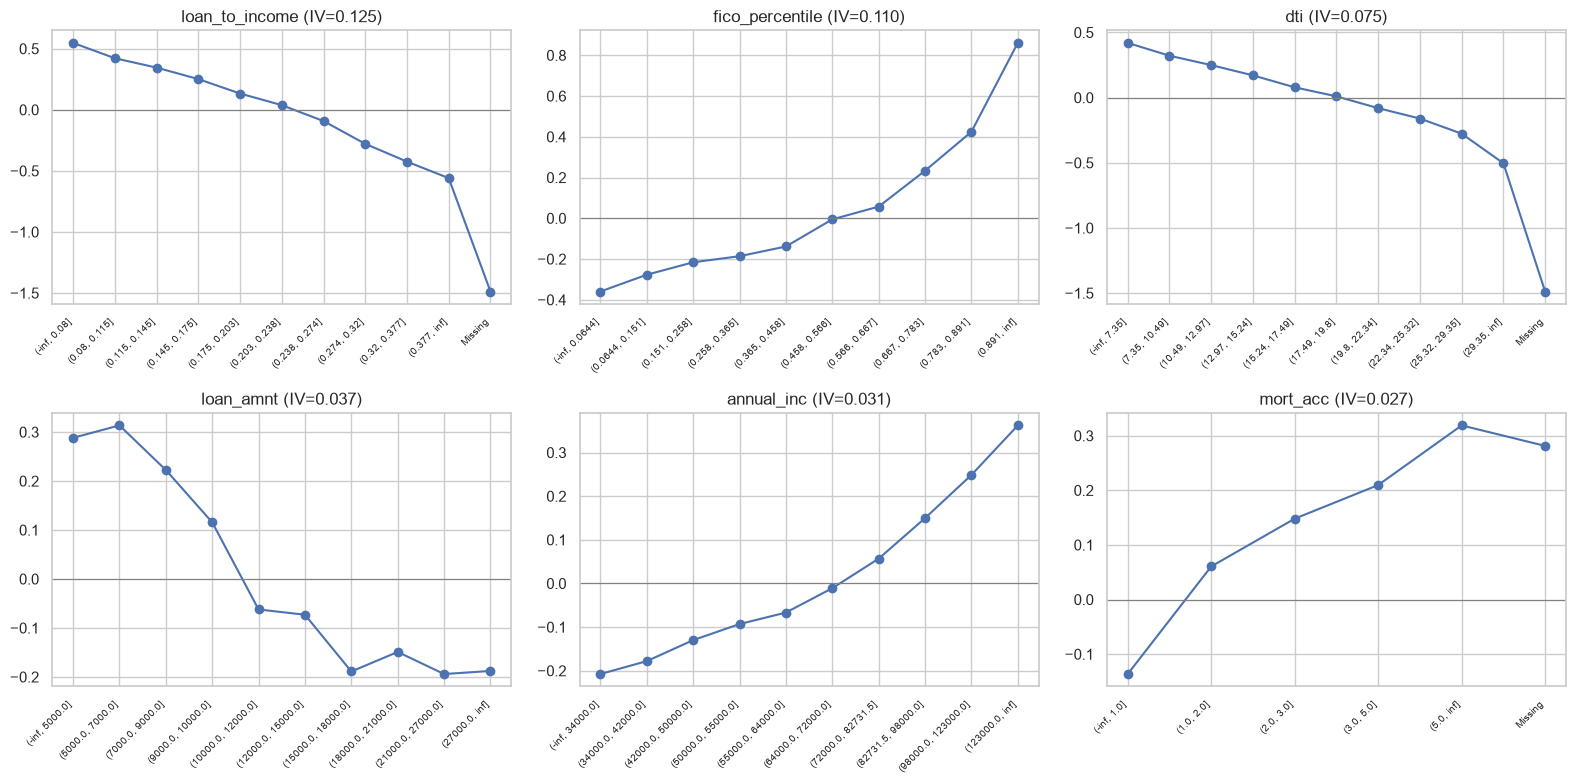

In [7]:
def sort_bins(tab):
    def sort_key(bin_label):
        if isinstance(bin_label, pd.Interval):
            return (0, bin_label.left)
        return (1, 0)
    order = sorted(tab.index, key=sort_key)
    return tab.loc[order]


top_numeric = [f for f in SELECTED_FEATURES if f in NUMERIC_FEATURES][:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, top_numeric):
    tab = sort_bins(woe_tables[feat])
    ax.plot(range(len(tab)), tab["woe"], marker="o")
    ax.set_xticks(range(len(tab)))
    ax.set_xticklabels([str(i) for i in tab.index], rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{feat} (IV={iv_summary[feat]:.3f})")
    ax.axhline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Transform train & test to WOE features, fit logistic regression

In [8]:
def transform_to_woe(data, features):
    out = pd.DataFrame(index=data.index)
    for feat in features:
        woe_tab = woe_tables[feat]
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        out[feat] = binned.map(woe_tab["woe"]).fillna(0.0)
    return out

X_train = transform_to_woe(train, SELECTED_FEATURES)
X_test = transform_to_woe(test, SELECTED_FEATURES)
y_train = train["is_default"].values
y_test = test["is_default"].values

model = LogisticRegression(solver="lbfgs")
model.fit(X_train, y_train)

coef_table = pd.Series(model.coef_[0], index=SELECTED_FEATURES).sort_values()
print("Intercept:", model.intercept_[0])
coef_table

Intercept: -1.4886681724300361


fico_percentile       -1.027197
term_months           -0.970662
home_ownership        -0.723279
dti                   -0.661672
mort_acc              -0.635294
loan_to_income        -0.415137
verification_status   -0.361336
annual_inc            -0.303824
loan_amnt              0.181484
revol_util             0.401016
dtype: float64

Every WOE coefficient should be **negative**. A positive coefficient signals a badly-behaved variable (as `revol_util` has been throughout this project — likely multicollinearity, not a real effect).

In [9]:
bad_sign = coef_table[coef_table > 0]
if len(bad_sign):
    print("WARNING - unexpected positive coefficients:", bad_sign.index.tolist())
else:
    print("All coefficients have the expected negative sign.")

WARNING - unexpected positive coefficients: ['loan_amnt', 'revol_util']


## 6. Out-of-sample performance: AUC, Gini, KS

In [10]:
def ks_statistic(y_true, y_score):
    order = np.argsort(y_score)
    y_true_sorted = np.array(y_true)[order]
    cum_bad = np.cumsum(y_true_sorted) / y_true_sorted.sum()
    cum_good = np.cumsum(1 - y_true_sorted) / (1 - y_true_sorted).sum()
    return np.max(np.abs(cum_bad - cum_good))


def report_performance(y_true, proba, label):
    auc = roc_auc_score(y_true, proba)
    gini = 2 * auc - 1
    ks = ks_statistic(y_true, proba)
    print(f"{label:>12}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")
    return auc, gini, ks

train_proba = model.predict_proba(X_train)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

train_perf = report_performance(y_train, train_proba, "Train (IS)")
test_perf = report_performance(y_test, test_proba, "Test (OOS)")

print("\nFor reference, scorecard.ipynb (v1, fico_percentile only) scored:")
print("  Train (IS): AUC=0.6892  Gini=0.3785  KS=0.2712")
print("  Test (OOS): AUC=0.6763  Gini=0.3527  KS=0.2489")

  Train (IS): AUC=0.6907  Gini=0.3813  KS=0.2742


  Test (OOS): AUC=0.6789  Gini=0.3578  KS=0.2534

For reference, scorecard.ipynb (v1, fico_percentile only) scored:
  Train (IS): AUC=0.6892  Gini=0.3785  KS=0.2712
  Test (OOS): AUC=0.6763  Gini=0.3527  KS=0.2489


## 7. Convert to a points-based scorecard

In [11]:
BASE_SCORE = 600
BASE_ODDS = 50
PDO = 20

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
n_features = len(SELECTED_FEATURES)

scorecard_rows = []
for feat, coef in zip(SELECTED_FEATURES, model.coef_[0]):
    tab = woe_tables[feat]
    for bin_label, row in tab.iterrows():
        points = -(coef * row["woe"] + model.intercept_[0] / n_features) * factor + offset / n_features
        scorecard_rows.append({
            "feature": feat,
            "bin": bin_label,
            "n_train": int(row["n"]),
            "bad_rate_train": row["bad"] / row["n"],
            "woe": row["woe"],
            "points": round(points, 1),
        })

scorecard = pd.DataFrame(scorecard_rows)
scorecard.head(20)

,feature,bin,n_train,bad_rate_train,woe,points
0,term_months,36.0,618584,0.138954,0.336202,62.4
1,term_months,60.0,208022,0.318952,-0.729206,32.6
2,loan_to_income,"(-inf, 0.08]",85072,0.115561,0.547340,59.6
3,loan_to_income,"(0.08, 0.115]",80254,0.129015,0.421880,58.1
4,loan_to_income,"(0.115, 0.145]",82682,0.137902,0.345019,57.1
5,loan_to_income,"(0.145, 0.175]",82894,0.149432,0.251260,56.0
6,loan_to_income,"(0.175, 0.203]",82400,0.165085,0.133069,54.6
7,loan_to_income,"(0.203, 0.238]",82660,0.178635,0.037822,53.5
8,loan_to_income,"(0.238, 0.274]",82698,0.198542,-0.092361,51.9
9,loan_to_income,"(0.274, 0.32]",85740,0.229904,-0.278938,49.7


In [12]:
def compute_scores(X_woe):
    log_odds_bad = model.intercept_[0] + X_woe.values @ model.coef_[0]
    return offset - factor * log_odds_bad

train["score"] = compute_scores(X_train)
test["score"] = compute_scores(X_test)

print(train["score"].describe())
print(test["score"].describe())

count    826606.000000
mean        534.455107
std          20.704821
min         470.734908
25%         521.553632
50%         535.583581
75%         548.005615
max         597.207279
Name: score, dtype: float64
count    293105.000000
mean        535.106640
std          19.812597
min         452.187397
25%         523.370493
50%         535.628936
75%         547.641700
max         596.835770
Name: score, dtype: float64


In [13]:
def points_lookup(data, features):
    total = pd.Series(0.0, index=data.index)
    for feat in features:
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        points_map = scorecard[scorecard["feature"] == feat].set_index("bin")["points"]
        total = total + binned.map(points_map).fillna(0.0)
    return total

sample_idx = train.sample(2000, random_state=0).index
points_check = points_lookup(train.loc[sample_idx], SELECTED_FEATURES)
score_check = pd.Series(compute_scores(X_train.loc[sample_idx]), index=sample_idx)
max_diff = (points_check - score_check).abs().max()
print(f"Max |points-table score - compute_scores()| over sample: {max_diff:.4f}")
assert max_diff < 1.0, "Points table and compute_scores() disagree — sign/scaling bug."

Max |points-table score - compute_scores()| over sample: 0.2666


In [14]:
train_score_check = pd.qcut(train["score"], 5, duplicates="drop")
direction_check = train.groupby(train_score_check, observed=True)["is_default"].mean()
print(direction_check)
assert direction_check.iloc[0] > direction_check.iloc[-1], "Score is inverted."
print("Score direction confirmed: higher score -> lower default rate.")

score
(470.73400000000004, 517.216]    0.358528
(517.216, 530.795]               0.215667
(530.795, 540.235]               0.158885
(540.235, 551.216]               0.119096
(551.216, 597.207]               0.069084
Name: is_default, dtype: float64
Score direction confirmed: higher score -> lower default rate.


## 8. Calibration on the out-of-time test set

In [15]:
test["score_band"] = pd.qcut(test["score"], 10, duplicates="drop")
calibration = test.groupby("score_band", observed=True).agg(
    n=("is_default", "size"),
    actual_default_rate=("is_default", "mean"),
    avg_score=("score", "mean"),
).sort_values("avg_score", ascending=False)
calibration

,n,actual_default_rate,avg_score
score_band,,,
"(560.33, 596.836]",29311,0.066971,569.699870
"(550.924, 560.33]",29310,0.119379,555.175346
"(544.864, 550.924]",29311,0.149841,547.730549
"(540.001, 544.864]",29310,0.177039,542.362588
"(535.629, 540.001]",29310,0.203344,537.786828
"(531.237, 535.629]",29311,0.231210,533.443973
"(526.332, 531.237]",29310,0.261651,528.863366
"(519.725, 526.332]",29311,0.294258,523.255950
"(508.428, 519.725]",29309,0.347572,514.663399


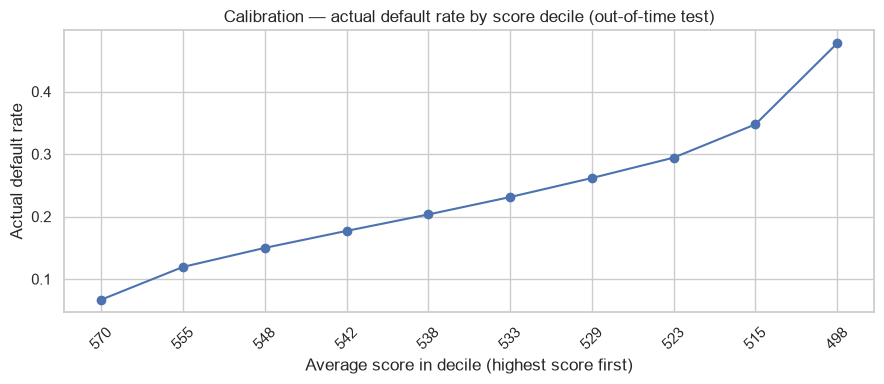

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(calibration)), calibration["actual_default_rate"], marker="o")
ax.set_xticks(range(len(calibration)))
ax.set_xticklabels([f"{v:.0f}" for v in calibration["avg_score"]], rotation=45)
ax.set_xlabel("Average score in decile (highest score first)")
ax.set_ylabel("Actual default rate")
ax.set_title("Calibration — actual default rate by score decile (out-of-time test)")
plt.tight_layout()
plt.show()

## 9. Population Stability Index (PSI): train vs. out-of-time test

In [17]:
def psi(expected, actual, bins=10):
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    edges = np.unique(edges)
    e_counts = np.histogram(expected, bins=edges)[0] / len(expected)
    a_counts = np.histogram(actual, bins=edges)[0] / len(actual)
    e_counts = np.where(e_counts == 0, 1e-6, e_counts)
    a_counts = np.where(a_counts == 0, 1e-6, a_counts)
    return np.sum((a_counts - e_counts) * np.log(a_counts / e_counts))

psi_value = psi(train["score"].values, test["score"].values)
print(f"PSI (train -> 2016 test): {psi_value:.4f}")

PSI (train -> 2016 test): 0.0077


## 10. Summary

- Same out-of-time design and leakage-avoidance rules as `scorecard.ipynb` (see
  that notebook for the full rationale on excluding LC's own grade/rate and on
  handling FICO as a rolling percentile).
- New features tested: `credit_history_years`, `loan_to_income`,
  `mths_since_last_delinq`, `mths_since_last_record`, `mths_since_last_major_derog`,
  `acc_now_delinq`, `tax_liens`, `addr_state`. Of these, only `loan_to_income`
  cleared the IV bar (IV = 0.125 — the second-strongest predictor in the model,
  behind only `term_months`). The rest were dropped for IV < 0.02.
- **Result: a real but modest improvement over v1.** Out-of-time test Gini rose
  from 0.3527 (v1, `fico_percentile`-only) to 0.3578 (v2, +`loan_to_income`) — about
  a 1.4% relative gain. KS and AUC moved by similarly small amounts. `loan_to_income`
  earned its place; the other seven new features did not.
- **New instability introduced: `loan_amnt`'s coefficient flipped positive.**
  `loan_to_income` is literally `loan_amnt / annual_inc`, so the two features share
  a component and are highly correlated — this is a textbook multicollinearity
  symptom, not a sign the underlying relationship reversed (same story as
  `revol_util`'s persistent positive coefficient throughout this project, likely for
  unrelated reasons). A natural follow-up refinement would be dropping `loan_amnt`
  in favor of `loan_to_income` (which carries far more IV on its own) rather than
  keeping both.
- `revol_bal_to_limit` and a credit-mix ratio were deliberately excluded this round
  due to vintage-driven missingness in their underlying fields — see the intro.